In [3]:
from collections import defaultdict

import nibabel

from mri_loader import Subject, MRI
from nilearn.glm.first_level import FirstLevelModel

import pandas as pd
import numpy as np

from stats import *




In [4]:
# for meet: maybe event time != process time

subject_ids = set(range(1, 34))
subject_ids -= {1, 3, 13, 22, 32, 33}  # fucked data

subject_ids -= set(range(27, 34))  # exclude SCZ

# subject_ids = list(subject_ids)

run_ids = list(range(1,5))

print(subject_ids, run_ids)

{2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26} [1, 2, 3, 4]


In [5]:

exclude_inflexion = set()


for subject in subject_ids:
    try:
        dataset = Subject(subject, run_ids)

        low_inflexion, high_inflexion = dataset.compute_inflexions()

        if low_inflexion < 0.1 or high_inflexion > 0.9 or high_inflexion < 0.5 or low_inflexion > 0.5:
            print(low_inflexion, high_inflexion)
            exclude_inflexion.add(subject)
    except:
        exclude_inflexion.add(subject)
        continue



0.07072072072072072 0.7247747747747747
0.2806306306306306 0.3842342342342342
0.07072072072072072 0.7490990990990991
0.06171171171171171 0.6490990990990991
0.05630630630630631 0.768018018018018
0.09234234234234234 0.7599099099099099
0.09684684684684684 0.7391891891891892


In [6]:
exclude_inflexion

{8, 9, 10, 12, 20, 23, 24, 25}

In [7]:
Subject(list(subject_ids)[0], run_ids).sample_mask

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 18

In [8]:
labels_col = "morph level"
# labels_col = "response"


In [9]:
subject_ids -= exclude_inflexion

subject_ids

{2, 4, 5, 6, 7, 11, 14, 15, 16, 17, 18, 19, 21, 26}

In [10]:
# subject_ids = set(range(27, 34))  # override, run on SCZ

In [11]:
len(subject_ids)

14

In [12]:

global_z_map = {}

contrast_list = [{"+": ["high"], "-": ["low"]},  # high > low
                 {"+": ["undecided"], "-": ["high", "low"]},]  # undecided > high + low

scale = [["25", "35"], ["35", "45"], ["45", "55"], ["55", "65"], ["65", "75"], ["75", "85"], ["85", "95"]]
to_subtract = {"-": ["5", "15"]}

for values in scale:
    contrast_list.append({
        "+": values,
        **to_subtract
    })

if labels_col == "response":
    contrast_list = [{"+": ["1"], "-": ["0"]}]  # override

if True:
    contrast_list = [{"+": ["button"], "-": ["unpressed"]}]

for classes in contrast_list:
    name = contrast_name(classes)
    global_z_map[name] = []

global_z_map

{'button > unpressed': []}

In [13]:

skipped = []

for subject in subject_ids:

    try:
        dataset = Subject(subject, run_ids, confound_mode="full", volumes_offset=0)
        dataset.load()

        images, times, labels = dataset.get_data(labels_col=labels_col, morph_response=True)
        low_inflexion, high_inflexion = dataset.compute_inflexions()

        sample_mask = dataset.sample_mask
    except Exception as e:
        print("Skipping subject ", subject)
        print(e)
        skipped.append(subject)
        continue

    print(f"{subject=} {low_inflexion=}, {high_inflexion=}")

    labels_class = set(labels)

    events = pd.DataFrame(
        {'onset': times,
         'trial_type': labels,
         'duration': 2.5}
    )

    repetition_time = dataset.repetition_time
    fmri_glm = FirstLevelModel(t_r=repetition_time,
              drift_model='polynomial',
              drift_order=3,
              hrf_model='spm',
              mask_img=dataset.brain_mask,
              smoothing_fwhm=4,
              n_jobs=-1)

    fmri_glm = fmri_glm.fit(images, events, sample_masks=sample_mask)
    # fmri_glm = fmri_glm.fit(images, events)

    design_matrix = fmri_glm.design_matrices_[0]

    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        str(column): contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }

    if labels_col == "morph level":

        low_contrast_columns = []
        high_contrast_columns = []
        undecided_contrast_columns = []
        button_contrast_columns = []
        unpressed_contrast_columns = []

        morph_columns = defaultdict(list)

        for key, column in contrasts.items():
            try:
                key_numeric = float(key.split("_")[0]) / 100
                key_parsed = str(int(key_numeric * 100))
                morph_columns[key_parsed].append(column)

                resp = int(key.split("_")[-1])
                if resp == 1:
                    button_contrast_columns.append(column)
                else:
                    unpressed_contrast_columns.append(column)

                if key_numeric < low_inflexion:
                    low_contrast_columns.append(column)

                elif key_numeric > high_inflexion:
                    high_contrast_columns.append(column)

                else:
                    undecided_contrast_columns.append(column)

            except ValueError:
                continue

        contrasts["low"]       = np.sum(low_contrast_columns, axis=0)
        contrasts["high"]      = np.sum(high_contrast_columns, axis=0)
        contrasts["undecided"] = np.sum(undecided_contrast_columns, axis=0)
        contrasts["button"]    = np.sum(button_contrast_columns, axis=0)
        contrasts["unpressed"] = np.sum(unpressed_contrast_columns, axis=0)

        for key, cols in morph_columns.items():
            contrasts[key] = np.sum(cols, axis=0)

    for contrast in contrast_list:

        glm_contrast_vector  = np.sum(contrasts[column] for column in contrast["+"])
        if '-' in contrast:
            glm_contrast_vector -= np.sum(contrasts[column] for column in contrast["-"])

        z_score = fmri_glm.compute_contrast(glm_contrast_vector, output_type="z_score")
        name = contrast_name(contrast)

        global_z_map[name].append(z_score)




subject=2 low_inflexion=np.float64(0.2698198198198198), high_inflexion=np.float64(0.613063063063063)
subject=4 low_inflexion=np.float64(0.3202702702702702), high_inflexion=np.float64(0.7229729729729729)
subject=5 low_inflexion=np.float64(0.2554054054054054), high_inflexion=np.float64(0.768018018018018)
subject=6 low_inflexion=np.float64(0.2734234234234234), high_inflexion=np.float64(0.7103603603603603)
subject=7 low_inflexion=np.float64(0.1725225225225225), high_inflexion=np.float64(0.7238738738738738)
subject=11 low_inflexion=np.float64(0.2905405405405405), high_inflexion=np.float64(0.7076576576576576)
subject=14 low_inflexion=np.float64(0.20045045045045046), high_inflexion=np.float64(0.7977477477477477)
subject=15 low_inflexion=np.float64(0.25360360360360357), high_inflexion=np.float64(0.6527027027027027)
subject=16 low_inflexion=np.float64(0.11666666666666667), high_inflexion=np.float64(0.7373873873873874)
subject=17 low_inflexion=np.float64(0.2734234234234234), high_inflexion=np.fl

In [14]:
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from brain_map import find_region_names

from nilearn import datasets

import matplotlib.pyplot as plt


In [ ]:
z_map_subjects = set(subject_ids)
z_map_subjects -= set(skipped)

plt.style.use('dark_background')

if False:  # avoid plot each time

    for contrast_name, images in global_z_map.items():
        for z_score, subject in zip(images, z_map_subjects):

            clean_z, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="bonferroni", cluster_threshold=5)
            cut_coords_list = [
                (0, 0, 0),
                (10, -20, 30),
                (-15, 10, 45),
            ]

            n_coords = len(cut_coords_list)

            fig, axes = plt.subplots(
                n_coords, 1,
                figsize=(15, 4 * n_coords)
            )

            fig.suptitle(contrast_name, fontweight="bold")

            bg_run = MRI(subject, 1)

            for ax, coords in zip(axes, cut_coords_list):
                plot_stat_map(
                    clean_z,
                    display_mode='ortho',
                    cut_coords=coords,
                    axes=ax,
                    bg_img=bg_run.background,
                    title=f"Ortho @ {coords}",
                    colorbar=True
                )

            plt.tight_layout()
            fname = contrast_name.replace(' ', '_').replace('>', 'over')
            plt.savefig(f"graphs/contrasts/sub-{subject}-contrast-{fname}.png")

In [ ]:

atlas_name = 'cort-maxprob-thr0-1mm'
harvard = datasets.fetch_atlas_harvard_oxford(atlas_name=atlas_name)

atlas_img = harvard.maps
labels = harvard.labels

regions_activated = {}

for contrast_name, images in global_z_map.items():
    regions_activated[contrast_name] = []

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.01, height_control="bonferroni", cluster_threshold=5)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=5
        )

        pos = [(x,y,z) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        try:
            indexes, regions_names = find_region_names(pos, atlas_img, labels=labels)
        except Exception as e:
            print(e)
            continue

        regions_names = list(set(str(v) for v in regions_names))

        regions_activated[contrast_name].append(regions_names)

        print(f"{contrast_name=}, {regions_names=}")


In [13]:
import pandas as pd



In [14]:

regions_activated_np = {}
regions_count = {}

for k, v in regions_activated.items():
    regions_activated_np[k] = np.array(v, dtype=object)

    regions_activated_np[k] = np.concatenate(regions_activated[k])

    regions_count[k] = np.unique_counts(regions_activated_np[k])

regions_count

{'1 > 0': UniqueCountsResult(values=array(['Central Opercular Cortex', 'Postcentral Gyrus'], dtype='<U32'), counts=array([1, 1]))}

In [15]:

df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in regions_activated_np.items()]))

for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(6))


--- 1 > 0 ---
1 > 0
Postcentral Gyrus           1
Central Opercular Cortex    1
Name: count, dtype: int64


In [16]:
summary = pd.DataFrame({
    col.replace(' ', ''): df[col].value_counts()
    for col in df.columns
})

summary = summary.fillna(0)

summary

,1>0
1 > 0,
Postcentral Gyrus,1
Central Opercular Cortex,1


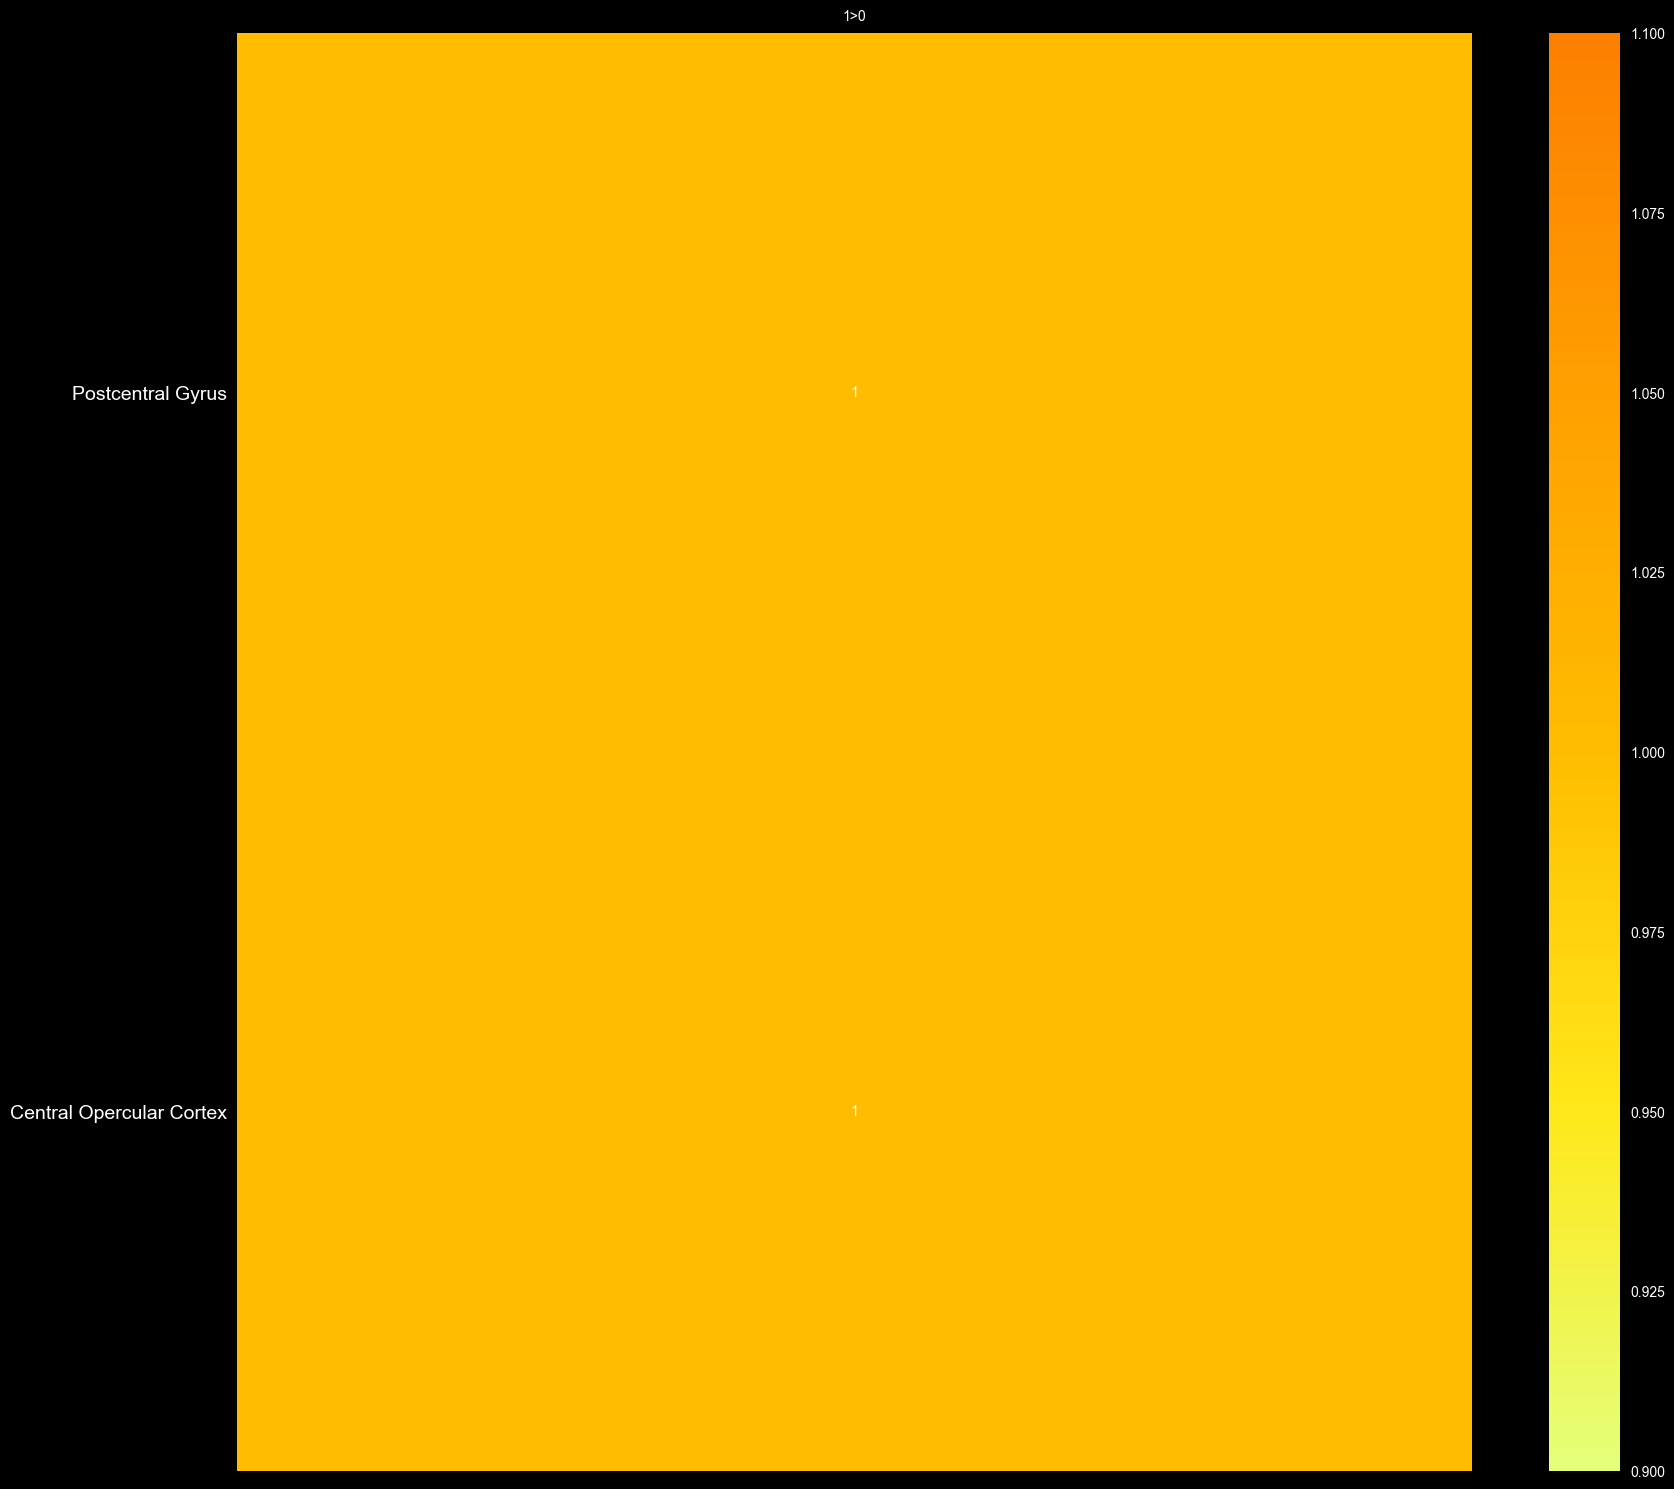

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(summary.columns)))
ax.set_yticks(range(len(summary)))
ax.set_xticklabels(summary.columns, fontsize=10)
ax.set_yticklabels(summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(summary.index)):
    for j in range(len(summary.columns)):
        ax.text(j, i, f'{summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [18]:
summary.style.format("{:.0f}").background_gradient(cmap='Blues')

,1>0
1 > 0,
Postcentral Gyrus,1
Central Opercular Cortex,1


In [15]:
from lib.mni_to_atlas import AtlasBrowser
import numpy as np

atlas = AtlasBrowser("AAL3")



In [16]:
mni_regions = {}

for contrast_name, images in global_z_map.items():
    mni_regions[contrast_name] = []

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.005, height_control="fdr", cluster_threshold=5)
#        clean, threshold = threshold_stats_img(z_score, alpha=0.01, height_control="bonferroni", cluster_threshold=5)
        table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)

        pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        for p in pos:
            try:
                projected_coords = atlas.project_to_nearest(p)
                projected_regions = atlas.find_regions(projected_coords)

                mni_regions[contrast_name].append(*projected_regions)
            except Exception as e:
                print(e)


In [18]:
mni_regions_concat = {}

for k, v in mni_regions.items():

    reg_list = np.array(v, dtype=object)

    mni_regions_concat[k] = reg_list

In [19]:
mni_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in mni_regions_concat.items()]))


In [20]:
mni_summary = pd.DataFrame({
    col.replace(' ', ''): mni_df[col].value_counts()
    for col in mni_df.columns
})

mni_summary = mni_summary.fillna(0)

mni_summary

,button>unpressed
button > unpressed,
Frontal_Inf_Tri_L,7
Frontal_Sup_2_R,5
Frontal_Sup_Medial_R,4
Cerebellum_8_R,4
OFCmed_R,3
Cerebellum_9_R,3
Fusiform_R,3
Frontal_Sup_Medial_L,3
Frontal_Sup_2_L,3


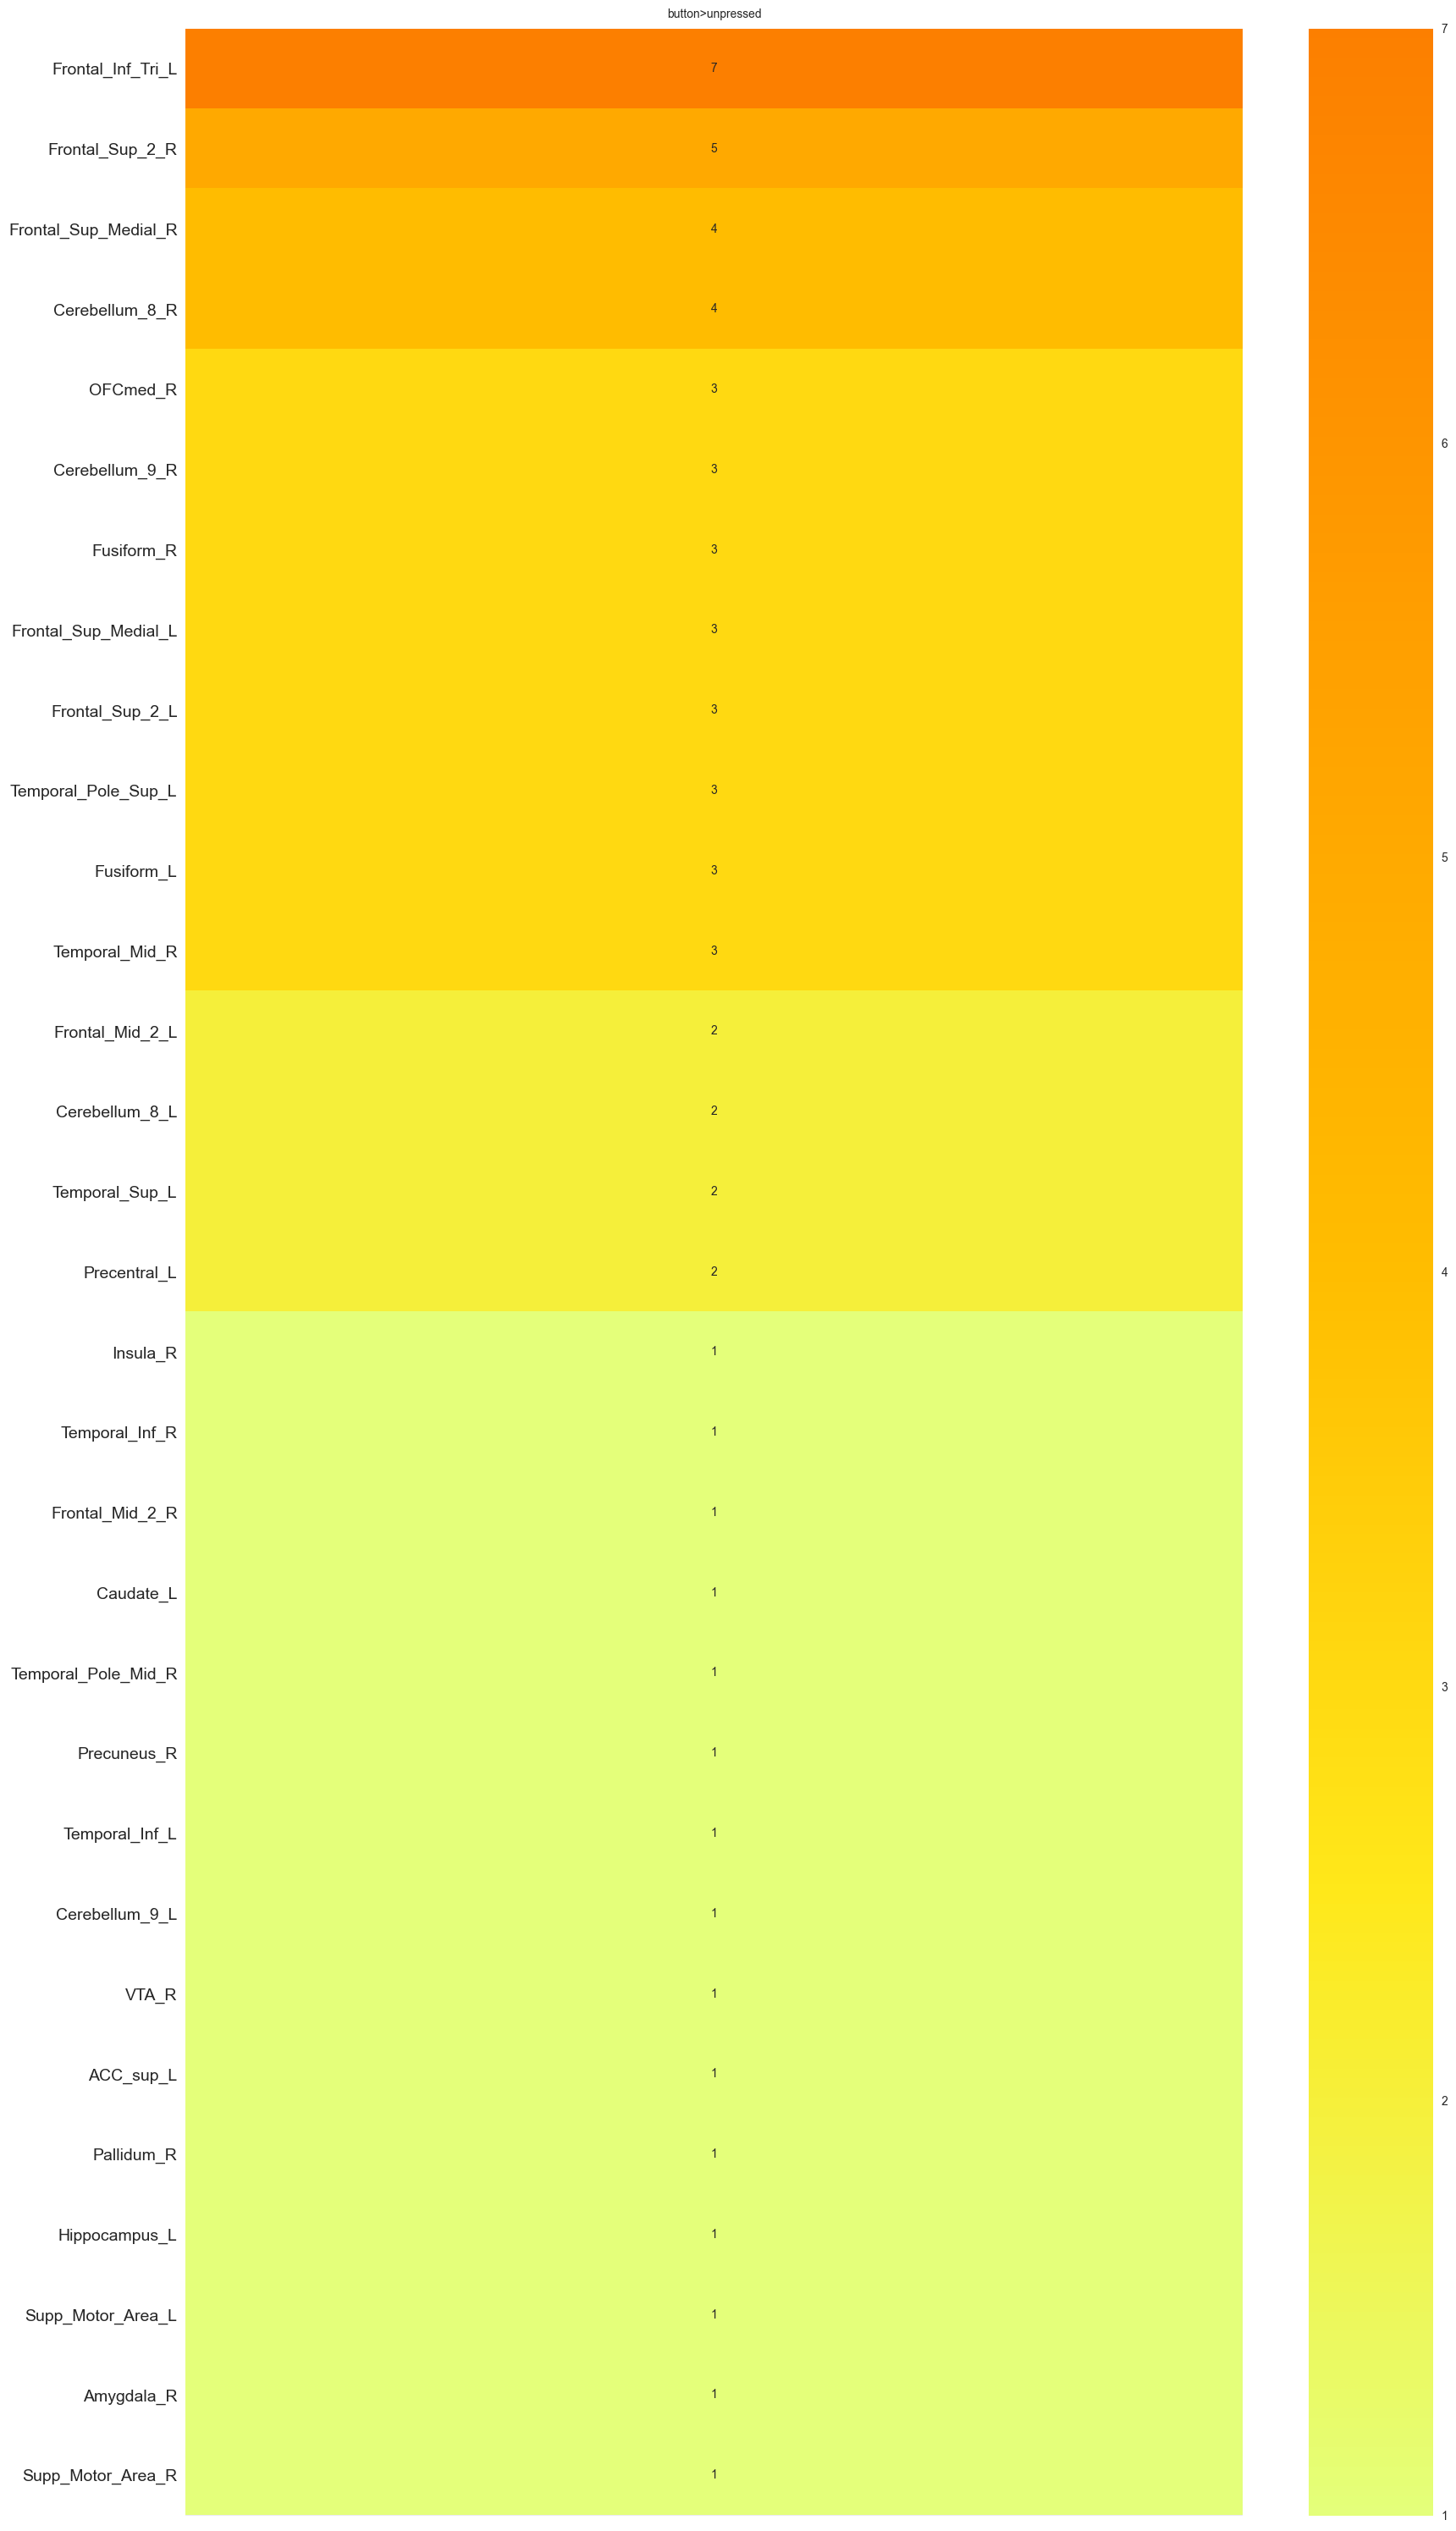

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 30))
im = ax.imshow(mni_summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(mni_summary.columns)))
ax.set_yticks(range(len(mni_summary)))
ax.set_xticklabels(mni_summary.columns, fontsize=10)
ax.set_yticklabels(mni_summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(mni_summary.index)):
    for j in range(len(mni_summary.columns)):
        ax.text(j, i, f'{mni_summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [26]:
import nibabel

for contrast_name, images in global_z_map.items():

    for z_score, subject in zip(images, z_map_subjects):

        fname = contrast_name.replace(' ', '_').replace('>', 'over')

        if False:
            nibabel.save(z_score, f"contrasts/smoothed_3mm/sub-{subject}-{fname}.nii.gz")
